# SIOC 251 - Homework 3 Monte Carlo Scattering

**Name:** Myles Jacobs

**Date:** 5/27/2026

## Part 3 - Cloud Effects
### 7.1: Model Construction

In [3]:
import os

# Create the figures directory if it does not already exist
figures_dir = 'figures'
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)
    print(f"Created directory: {figures_dir}/")
else:
    print(f"Directory {figures_dir}/ already exists.")

Directory figures/ already exists.


In [8]:
import numpy as np

def run_monte_carlo_cloudy(num_photons, theta_deg, omega_cloud=1.0, g_cloud=0.8, 
                                 lwc=0.30, tau_clear_total=0.1, r_eff=11.0, z_atm=10.0):
    """
    Flexible version of the 3-layer cloudy model to accommodate verification tests.
    """
    if theta_deg >= 90.0:
        return {"albedo": 1.0, "total_transmittance": 0.0, "absorptance": 0.0}

    # --- Geometry & Layer Properties ---
    z_base = 0.75  # km
    z_top = 1.0    # km
    H = 8.0        # km
    
    # Cloud Optical Depth
    if lwc == 0:
        tau_cloud = 0.0
    else:
        lwc_kg_m3 = lwc * 1e-3       
        r_eff_m = r_eff * 1e-6       
        rho_w = 1000.0               
        delta_z = 250.0              
        tau_cloud = (3 * lwc_kg_m3 * delta_z) / (2 * rho_w * r_eff_m) 
    
    # Clear sky optical depths
    frac_below = 1.0 - np.exp(-z_base / H)
    frac_above = np.exp(-z_top / H) - np.exp(-z_atm / H)
    
    tau_below = tau_clear_total * frac_below
    tau_above = tau_clear_total * frac_above
    
    beta_below = tau_below / z_base if z_base > 0 else 0
    beta_cloud = tau_cloud / (z_top - z_base)
    beta_above = tau_above / (z_atm - z_top) if (z_atm - z_top) > 0 else 0
    
    beta_max = max(beta_below, beta_cloud, beta_above)
    
    # Handle absolute vacuum edge case safely
    if beta_max == 0:
        return {
            "tau_cloud_calculated": 0.0,
            "direct_transmittance": 1.0,
            "diffuse_transmittance": 0.0,
            "total_transmittance": 1.0,
            "albedo": 0.0,
            "absorptance": 0.0
        }

    # --- Photon Initialization ---
    theta_rad = np.radians(theta_deg)
    phi_rad = 0.0

    kx = np.sin(theta_rad) * np.cos(phi_rad) * np.ones(num_photons)
    ky = np.sin(theta_rad) * np.sin(phi_rad) * np.ones(num_photons)
    kz = -np.cos(theta_rad) * np.ones(num_photons) 
    z = np.full(num_photons, z_atm)

    active = np.ones(num_photons, dtype=bool)
    scatters = np.zeros(num_photons, dtype=int)
    reflected = np.zeros(num_photons, dtype=bool)
    transmitted = np.zeros(num_photons, dtype=bool)
    absorbed = np.zeros(num_photons, dtype=bool)

    # --- Main Tracking Loop ---
    while np.any(active):
        N_active = np.sum(active)
        active_indices = np.where(active)[0]

        zeta = np.random.uniform(0, 1, N_active)
        L = -np.log(1 - zeta) / beta_max
        z_tentative = z[active] + L * kz[active]

        hit_ground = z_tentative <= 0
        hit_top = z_tentative >= z_atm

        transmitted[active_indices[hit_ground]] = True
        reflected[active_indices[hit_top]] = True
        active[active_indices[hit_ground]] = False
        active[active_indices[hit_top]] = False

        z[active_indices] = z_tentative

        interacting_indices = np.where(active)[0]
        N_int = len(interacting_indices)
        if N_int == 0:
            break

        z_int = z[interacting_indices]
        beta_local = np.zeros(N_int)
        omega_local = np.zeros(N_int)
        g_local = np.zeros(N_int)

        # Layer 3: Below Cloud
        mask3 = z_int <= z_base
        beta_local[mask3] = beta_below
        omega_local[mask3] = 1.0  
        g_local[mask3] = 0.0

        # Layer 2: Cloud
        mask2 = (z_int > z_base) & (z_int <= z_top)
        beta_local[mask2] = beta_cloud
        omega_local[mask2] = omega_cloud  # Custom verification target
        g_local[mask2] = g_cloud

        # Layer 1: Above Cloud
        mask1 = z_int > z_top
        beta_local[mask1] = beta_above
        omega_local[mask1] = 1.0  
        g_local[mask1] = 0.0

        # Woodcock rejection step
        zeta_col = np.random.uniform(0, 1, N_int)
        is_real_collision = zeta_col < (beta_local / beta_max)
        
        real_indices = interacting_indices[is_real_collision]
        N_real = len(real_indices)

        if N_real > 0:
            omega_real = omega_local[is_real_collision]
            g_real = g_local[is_real_collision]

            zeta_omega = np.random.uniform(0, 1, N_real)
            is_scatter = zeta_omega < omega_real
            is_absorbed = ~is_scatter

            absorbed[real_indices[is_absorbed]] = True
            active[real_indices[is_absorbed]] = False

            scatter_indices = real_indices[is_scatter]
            scatters[scatter_indices] += 1
            g_scat = g_real[is_scatter]
            N_scat = len(scatter_indices)

            if N_scat > 0:
                u = np.random.uniform(0, 1, N_scat)
                cos_Theta = np.zeros(N_scat)
                
                iso_mask = (g_scat == 0.0)
                hg_mask = ~iso_mask
                
                if np.any(iso_mask):
                    cos_Theta[iso_mask] = 2 * u[iso_mask] - 1
                if np.any(hg_mask):
                    g_h = g_scat[hg_mask]
                    u_h = u[hg_mask]
                    term = (1 - g_h**2) / (1 - g_h + 2 * g_h * u_h)
                    cos_Theta[hg_mask] = (1 + g_h**2 - term**2) / (2 * g_h)

                sin_Theta = np.sqrt(np.maximum(0, 1 - cos_Theta**2))
                Phi = np.random.uniform(0, 2 * np.pi, N_scat)

                kp_x = sin_Theta * np.cos(Phi)
                kp_y = sin_Theta * np.sin(Phi)
                kp_z = cos_Theta

                kx_s, ky_s, kz_s = kx[scatter_indices], ky[scatter_indices], kz[scatter_indices]
                zp_x, zp_y, zp_z = kx_s, ky_s, kz_s
                norm_xy = np.sqrt(kx_s**2 + ky_s**2)
                xp_x, xp_y, xp_z = np.zeros_like(kx_s), np.zeros_like(ky_s), np.zeros_like(kz_s)

                vertical = norm_xy < 1e-8
                not_vertical = ~vertical
                if np.any(vertical):
                    xp_x[vertical] = 1.0
                if np.any(not_vertical):
                    xp_x[not_vertical] = -ky_s[not_vertical] / norm_xy[not_vertical]
                    xp_y[not_vertical] = kx_s[not_vertical] / norm_xy[not_vertical]

                yp_x = zp_y * xp_z - zp_z * xp_y
                yp_y = zp_z * xp_x - zp_x * xp_z
                yp_z = zp_x * xp_y - zp_y * xp_x

                knew_x = kp_x * xp_x + kp_y * yp_x + kp_z * zp_x
                knew_y = kp_x * xp_y + kp_y * yp_y + kp_z * zp_y
                knew_z = kp_x * xp_z + kp_y * yp_z + kp_z * zp_z

                norm_knew = np.sqrt(knew_x**2 + knew_y**2 + knew_z**2)
                kx[scatter_indices] = knew_x / norm_knew
                ky[scatter_indices] = knew_y / norm_knew
                kz[scatter_indices] = knew_z / norm_knew

    direct = transmitted & (scatters == 0)
    diffuse = transmitted & (scatters > 0)

    return {
        "tau_cloud_calculated": tau_cloud,
        "direct_transmittance": np.sum(direct) / num_photons,
        "diffuse_transmittance": np.sum(diffuse) / num_photons,
        "total_transmittance": np.sum(transmitted) / num_photons,
        "albedo": np.sum(reflected) / num_photons,
        "absorptance": np.sum(absorbed) / num_photons
    }

# --- Execution Example ---
res = run_monte_carlo_cloudy(num_photons=100000, theta_deg=0.0)
print("--- Results ---")
print(f"Calculated Cloud Optical Depth: {res['tau_cloud_calculated']:.4f}")
print(f"Direct Transmittance:          {res['direct_transmittance']:.4f}")
print(f"Diffuse Transmittance:         {res['diffuse_transmittance']:.4f}")
print(f"Total Transmittance (Surface): {res['total_transmittance']:.4f}")
print(f"Albedo (Reflected to TOA):     {res['albedo']:.4f}")
print(f"Absorptance:                   {res['absorptance']:.4f}")

--- Results ---
Calculated Cloud Optical Depth: 10.2273
Direct Transmittance:          0.0001
Diffuse Transmittance:         0.4772
Total Transmittance (Surface): 0.4773
Albedo (Reflected to TOA):     0.5227
Absorptance:                   0.0000


### 7.2 Verification

**Test 1:** Let us set the single scatter albedo $\omega = 0$. This means our cloud is purely absorbing, so we should see absolutely no diffuse transmittance.

In [10]:
verf1 = run_monte_carlo_cloudy(num_photons=100000, theta_deg=0.0, omega_cloud=0.0)
print("--- Verification Test 1 ---")
print(f"Calculated Cloud Optical Depth: {verf1['tau_cloud_calculated']:.4f}")
print(f"Direct Transmittance:          {verf1['direct_transmittance']:.4f}")
print(f"Diffuse Transmittance:         {verf1['diffuse_transmittance']:.4f}")
print(f"Total Transmittance (Surface): {verf1['total_transmittance']:.4f}")
print(f"Albedo (Reflected to TOA):     {verf1['albedo']:.4f}")
print(f"Absorptance:                   {verf1['absorptance']:.4f}")

--- Verification Test 1 ---
Calculated Cloud Optical Depth: 10.2273
Direct Transmittance:          0.0000
Diffuse Transmittance:         0.0000
Total Transmittance (Surface): 0.0000
Albedo (Reflected to TOA):     0.0293
Absorptance:                   0.9707


As predicted, we see only absorptance and minimal albedo.

**Test 2:** Let us set the LWC and tau_clear_total to zero, to simulate a complete vaccuum. We should expect to see exclusively direct transmittance.

In [11]:
verf2 = run_monte_carlo_cloudy(num_photons=100000, theta_deg=0.0, lwc = 0.0, tau_clear_total = 0.0)
print("--- Verification Test 1 ---")
print(f"Calculated Cloud Optical Depth: {verf2['tau_cloud_calculated']:.4f}")
print(f"Direct Transmittance:          {verf2['direct_transmittance']:.4f}")
print(f"Diffuse Transmittance:         {verf2['diffuse_transmittance']:.4f}")
print(f"Total Transmittance (Surface): {verf2['total_transmittance']:.4f}")
print(f"Albedo (Reflected to TOA):     {verf2['albedo']:.4f}")
print(f"Absorptance:                   {verf2['absorptance']:.4f}")

--- Verification Test 1 ---
Calculated Cloud Optical Depth: 0.0000
Direct Transmittance:          1.0000
Diffuse Transmittance:         0.0000
Total Transmittance (Surface): 1.0000
Albedo (Reflected to TOA):     0.0000
Absorptance:                   0.0000


**Excellent**

### 7.3 Questions

In [12]:
# --- Section 7.3a Calculation ---
F_down = 1361.0  # TOA Incoming Shortwave Flux (W/m^2)

# 1. Run Cloudy Scenario
res_cloudy = run_monte_carlo_cloudy(num_photons=100000, theta_deg=0.0, lwc=0.30, tau_clear_total=0.1)
alpha_cloudy = res_cloudy['albedo']

# 2. Run Clear Scenario (LWC = 0)
res_clear = run_monte_carlo_cloudy(num_photons=100000, theta_deg=0.0, lwc=0.0, tau_clear_total=0.1)
alpha_clear = res_clear['albedo']

# 3. Calculate CRE
cre_toa = F_down * (alpha_clear - alpha_cloudy)

print(f"Cloudy Albedo:      {alpha_cloudy:.4f}")
print(f"Clear-Sky Albedo:   {alpha_clear:.4f}")
print(f"SW CRE at the TOA:  {cre_toa:.2f} W m^-2")

Cloudy Albedo:      0.5224
Clear-Sky Albedo:   0.0330
SW CRE at the TOA:  -666.13 W m^-2


Matplotlib is building the font cache; this may take a moment.


Running sensitivity analysis for R_eff...
  R_eff =   5.5 µm | Cloud Optical Depth =  20.45 | CRE =  -906.3 W m^-2
  R_eff =   7.3 µm | Cloud Optical Depth =  15.34 | CRE =  -811.1 W m^-2
  R_eff =   9.2 µm | Cloud Optical Depth =  12.27 | CRE =  -732.5 W m^-2
  R_eff =  11.0 µm | Cloud Optical Depth =  10.23 | CRE =  -667.4 W m^-2
  R_eff =  12.8 µm | Cloud Optical Depth =   8.77 | CRE =  -606.3 W m^-2
  R_eff =  14.7 µm | Cloud Optical Depth =   7.67 | CRE =  -559.9 W m^-2
  R_eff =  16.5 µm | Cloud Optical Depth =   6.82 | CRE =  -515.0 W m^-2
  R_eff =  18.3 µm | Cloud Optical Depth =   6.14 | CRE =  -476.4 W m^-2
  R_eff =  20.2 µm | Cloud Optical Depth =   5.58 | CRE =  -438.8 W m^-2
  R_eff =  22.0 µm | Cloud Optical Depth =   5.11 | CRE =  -409.8 W m^-2

Calculated 1st Aerosol Indirect Effect Slope:
Slope = 29.2829 W m^-2 µm^-1


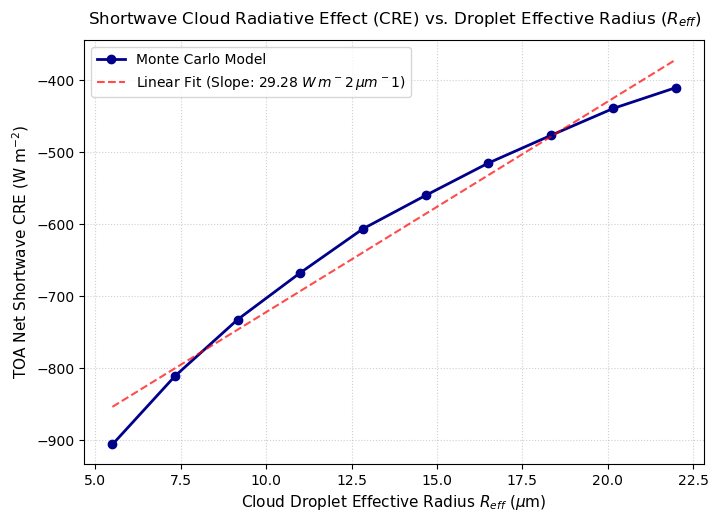

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define the Simulation Parameters ---
F_down = 1361.0              # TOA Incoming Shortwave Solar Flux (W m^-2)
N_PHOTONS = 100000           # Number of photons per run for statistical stability
BASE_R_EFF = 11.0            # Baseline effective radius (microns)

# Range of R_eff from half (5.5 µm) to double (22.0 µm) the initial value
r_eff_range = np.linspace(5.5, 22.0, 10)

cloudy_albedos = []
cre_values = []

print("Running sensitivity analysis for R_eff...")

# --- 2. Calculate the Clear-Sky Reference Albedo ---
# Held constant because it does not depend on cloud microphysics (LWC = 0)
res_clear = run_monte_carlo_verification(
    num_photons=N_PHOTONS, theta_deg=0.0, lwc=0.0, tau_clear_total=0.1
)
alpha_clear = res_clear['albedo']

# --- 3. Loop over the Range of R_eff values ---
for r in r_eff_range:
    res_cloudy = run_monte_carlo_verification(
        num_photons=N_PHOTONS, 
        theta_deg=0.0, 
        omega_cloud=1.0, 
        g_cloud=0.8, 
        lwc=0.30, 
        tau_clear_total=0.1, 
        r_eff=r
    )
    alpha_cloudy = res_cloudy['albedo']
    cloudy_albedos.append(alpha_cloudy)
    
    # Calculate TOA Shortwave CRE: F_down * (alpha_clear - alpha_cloudy)
    cre = F_down * (alpha_clear - alpha_cloudy)
    cre_values.append(cre)
    print(f"  R_eff = {r:5.1f} µm | Cloud Optical Depth = {res_cloudy['tau_cloud_calculated']:6.2f} | CRE = {cre:7.1f} W m^-2")

# --- 4. Calculate the Slope of the Line (Linear Regression) ---
# Fits a 1st-degree polynomial (y = mx + b) to extract the slope 'm'
slope, intercept = np.polyfit(r_eff_range, cre_values, 1)

print("\n==================================================")
print(f"Calculated 1st Aerosol Indirect Effect Slope:")
print(f"Slope = {slope:.4f} W m^-2 µm^-1")
print("==================================================")

# --- 5. Generate and Save the Plot ---
plt.figure(figsize=(8, 5.5))
plt.plot(r_eff_range, cre_values, 'o-', color='darkblue', linewidth=2, label='Monte Carlo Model')
plt.plot(r_eff_range, slope * r_eff_range + intercept, '--', color='red', alpha=0.7, 
         label=f'Linear Fit (Slope: {slope:.2f} $W\\,m^{-2}\\,\\mu m^{-1}$)')

plt.title('Shortwave Cloud Radiative Effect (CRE) vs. Droplet Effective Radius ($R_{eff}$)', fontsize=12, pad=12)
plt.xlabel('Cloud Droplet Effective Radius $R_{eff}$ ($\mu$m)', fontsize=11)
plt.ylabel('TOA Net Shortwave CRE (W m$^{-2}$)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)

# Save the figure to the designated figures/ directory required by the repo structure
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/figure1.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The positive direction of the calculated slope means that as $R_{eff}$ increases, the CRE becomes *less negative*. This is because when we hold LWC constant, dividing this water into smaller and smaller droplets dramatically increases the surface area available to intercept photons. This is expressed through the inverse proportionality $\tau_{cloud} \propto 1/R_{eff}$.

This expression is reflected by the plot. For lower $R_{eff}$, we would see a higher cloud optical depth, leading to the observed highly reflective cloud value: $CRE \approx -900 W m^{-2} \micro m^{-1}$. And for higher $R_{eff}$, we would see a lower cloud optical depth, leading to the observed less reflective cloud value: $CRE \approx -400 W m^{-2} \micro m^{-1}$.

### 7.3 Student Investigation

**Question:** How does LWC of a cloud relate to transmittance fractions?

**Hypoyhesis:** If we assume the same baselines as the original model's cloud, only varying LWC, Direct/Diffuse transmittance should go down and up respectively with increasing LWC. Albedo should also increase with LWC. Since we're assuming $\omega = 1$ to be consistent with the base model, absorptance should remain zero.

Running LWC sensitivity analysis...
  LWC: 0.00 g m^-3 | Optical Depth:   0.00 | Albedo: 0.034 | Diffuse Trans: 0.033
  LWC: 0.07 g m^-3 | Optical Depth:   2.44 | Albedo: 0.183 | Diffuse Trans: 0.734
  LWC: 0.14 g m^-3 | Optical Depth:   4.87 | Albedo: 0.322 | Diffuse Trans: 0.671
  LWC: 0.21 g m^-3 | Optical Depth:   7.31 | Albedo: 0.432 | Diffuse Trans: 0.567
  LWC: 0.29 g m^-3 | Optical Depth:   9.74 | Albedo: 0.509 | Diffuse Trans: 0.491
  LWC: 0.36 g m^-3 | Optical Depth:  12.18 | Albedo: 0.572 | Diffuse Trans: 0.428
  LWC: 0.43 g m^-3 | Optical Depth:  14.61 | Albedo: 0.616 | Diffuse Trans: 0.384
  LWC: 0.50 g m^-3 | Optical Depth:  17.05 | Albedo: 0.656 | Diffuse Trans: 0.344
  LWC: 0.57 g m^-3 | Optical Depth:  19.48 | Albedo: 0.688 | Diffuse Trans: 0.312
  LWC: 0.64 g m^-3 | Optical Depth:  21.92 | Albedo: 0.715 | Diffuse Trans: 0.285
  LWC: 0.71 g m^-3 | Optical Depth:  24.35 | Albedo: 0.735 | Diffuse Trans: 0.265
  LWC: 0.79 g m^-3 | Optical Depth:  26.79 | Albedo: 0.752 | D

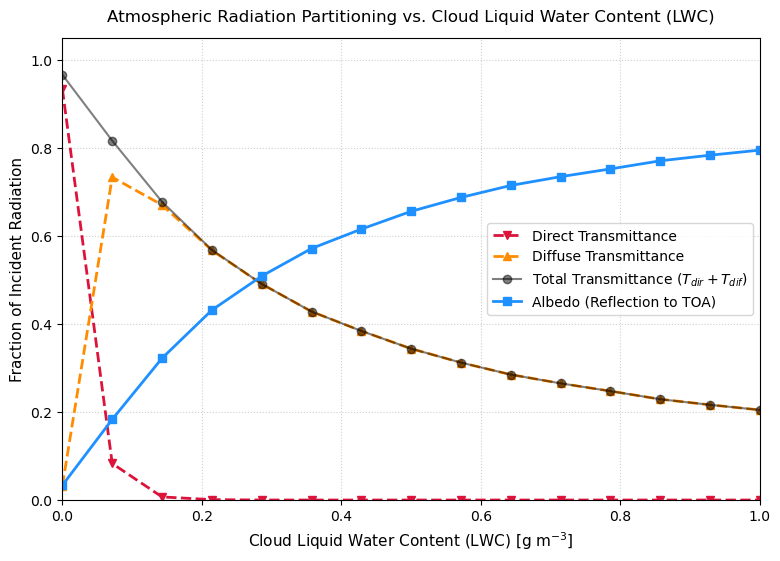

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Simulation Setup ---
N_PHOTONS = 100000          # Number of photons per run for clean statistics
THETA_DEG = 0.0             # Overhead sun

# Range of Liquid Water Content (LWC) from 0.0 (clear sky) to 1.0 g m^-3
lwc_range = np.linspace(0.0, 1.0, 15)

# Initialize lists to store our optical outputs
direct_trans = []
diffuse_trans = []
total_trans = []
albedos = []

print("Running LWC sensitivity analysis...")

# --- 2. Execute the Sweep Loop ---
for lwc_val in lwc_range:
    # Use our flexible 3-layer Monte Carlo model
    res = run_monte_carlo_verification(
        num_photons=N_PHOTONS,
        theta_deg=THETA_DEG,
        omega_cloud=1.0,     # Conservative scattering in the cloud
        g_cloud=0.8,         # Forward-scattering asymmetry parameter
        lwc=lwc_val,         # Sweeping over this variable
        tau_clear_total=0.1, # Base background clear sky optical depth
        r_eff=11.0           # Held constant at 11 microns
    )
    
    # Store results from this run
    direct_trans.append(res['direct_transmittance'])
    diffuse_trans.append(res['diffuse_transmittance'])
    total_trans.append(res['total_transmittance'])
    albedos.append(res['albedo'])
    
    print(f"  LWC: {lwc_val:.2f} g m^-3 | Optical Depth: {res['tau_cloud_calculated']:6.2f} | Albedo: {res['albedo']:.3f} | Diffuse Trans: {res['diffuse_transmittance']:.3f}")

# --- 3. Plotting the Results ---
plt.figure(figsize=(9, 6))

# Plot each component
plt.plot(lwc_range, direct_trans, 'v--', color='crimson', linewidth=2, label='Direct Transmittance')
plt.plot(lwc_range, diffuse_trans, '^--', color='darkorange', linewidth=2, label='Diffuse Transmittance')
plt.plot(lwc_range, total_trans, 'o-', color='black', linewidth=1.5, alpha=0.5, label='Total Transmittance ($T_{dir} + T_{dif}$)')
plt.plot(lwc_range, albedos, 's-', color='dodgerblue', linewidth=2, label='Albedo (Reflection to TOA)')

# Formatting details
plt.title('Atmospheric Radiation Partitioning vs. Cloud Liquid Water Content (LWC)', fontsize=12, pad=12)
plt.xlabel('Cloud Liquid Water Content (LWC) [g m$^{-3}$]', fontsize=11)
plt.ylabel('Fraction of Incident Radiation', fontsize=11)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='center right')

# Save to your repository's figures/ folder as required by assignment rules
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/lwc_sensitivity.png', dpi=300, bbox_inches='tight')

plt.show()

### Results

My hypothesis was **only partially correct**. I was right to expect albedo to monotonically rise and direct transmittance to monotonically fall, *however,* diffuse transmittance peaks and then gradually falls again with continuously rising LWC. This makes sense, given that at a certain point, a cloud so dense with water would force so many multiple scattering events that instead of travelling through the cloud, photons just end up just backscattered to space altogether.

### AI Usage

+ Tool Used: Gemini (Google)
+ How it was used: Gemini generated the bulk of the code of the original model, as well as the figures.
+ Parts checked independently: Model was verified at limiting cases by hand. (Section 7.2). Analyses/interpretation in markdown cells done by hand.